# Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import f1_score, recall_score, ConfusionMatrixDisplay

import kagglehub
import re
import os

# Load the IMDb Dataset

- Reference(Kaggle): [IMDB Dataset of 50K Movie Reviews](https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews)

In [4]:
path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")

print("Path to dataset files:", path)

df = pd.read_csv(os.path.join(path, "IMDB Dataset.csv"))
df.head()

Using Colab cache for faster access to the 'imdb-dataset-of-50k-movie-reviews' dataset.
Path to dataset files: /kaggle/input/imdb-dataset-of-50k-movie-reviews


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


# Data Analysis
- Check Class Balance
- Check Null value
- Check Duplicate Value

In [5]:
df['sentiment'].value_counts()

,count
sentiment,
positive,25000
negative,25000


In [6]:
df.isnull().sum()

,0
review,0
sentiment,0


In [7]:
df.duplicated().sum()

np.int64(418)

In [8]:
df.isna().sum()

,0
review,0
sentiment,0


# Data Visualization
- Pie-Chart to show class balance

([<matplotlib.patches.Wedge at 0x7baa0c4f48f0>,
 [Text(-0.09587128484418629, -1.0958141707161506, 'positive'),
  Text(0.10022869722726624, 1.1456239384074187, 'negative')],
 [Text(-0.05229342809682888, -0.5977168203906276, '50.0%'),
  Text(0.056651002780628734, 0.6475265738824539, '50.0%')])

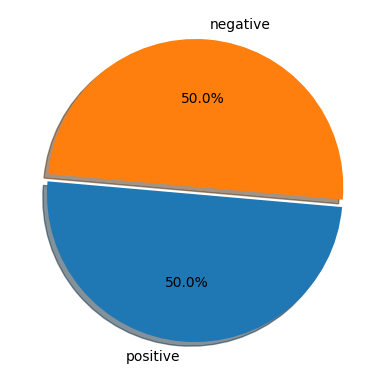

In [9]:
plt.pie(
    df["sentiment"].value_counts(),
    labels = ['positive', 'negative'],
    autopct='%1.1f%%',
    startangle=175,
    explode=(0, 0.05),
    shadow=True
)

# Data Preprocessing
- Remove HTML tags and URLs
- Convert text to lowercase
- Handle negation (e.g., `not good` to `not_good`)
- Remove numbers, punctuation, repeated words, and extra spaces

In [10]:
def preprocess_text(text: str):
    max_repeat = 3

    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'http\S+|www\S+', ' ', text)

    text = text.lower()

    text = re.sub(r"not\s+(\w+)", r"not_\1", text)

    text = re.sub(r'\d+', ' ', text)
    text = re.sub(r'[^\w\s]', ' ', text)

    words = text.split()
    refined = []
    count = 0

    for i in range(len(words)):
        if i > 0 and words[i] == words[i-1]:
            count += 1
        else:
            count = 1

        if count <= max_repeat:
            refined.append(words[i])

    text = " ".join(refined)
    text = re.sub(r'\s+', ' ', text)

    return text.strip()

In [11]:
df["review"] = df["review"].apply(preprocess_text)

# Train Test Split

In [12]:
X = df["review"] # Feature
y = df["sentiment"] # Target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
X_train

,review
39087,that s what i kept asking myself during the ma...
30893,i did not_watch the entire movie i could not_w...
45278,a touching love story reminiscent of in the mo...
16398,this latter day fulci schlocker is a totally a...
13653,first of all i firmly believe that norwegian m...
...,...
11284,shadow magic recaptures the joy and amazement ...
44732,i found this movie to be quite enjoyable and f...
38158,avoid this one it is a terrible movie so what ...
860,this production was quite a surprise for me i ...


# Text Vectorization
Convert `text` to `numeric` features


## TF-IDF
- Convert text into numerical vectors
- Remove stop words
- Limit features to 5000

In [14]:
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Model Train
**Multinomial Naive Bayes (MultinomialNB)** is a type of Naive Bayes classifier that works well for **text classification**. It calculates the probability of each class based on the **frequency of words** in the documents. MultinomialNB is simple, fast, and effective for datasets like movie reviews, where features are **word counts or TF-IDF values**.

In [15]:
model = MultinomialNB()
model.fit(X_train_vec, y_train)

y_train_pred = model.predict(X_train_vec)
y_pred = model.predict(X_test_vec)

train_acc = accuracy_score(y_train, y_train_pred)
val_acc = accuracy_score(y_test, y_pred)

print(f"Train Accuracy: {train_acc:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")

Train Accuracy: 0.8640
Validation Accuracy: 0.8540


# Model Evaluation

The performance of the Naive Bayes model was evaluated using *accuracy*, *precision*, *recall*, *F1-score*, and a *confusion matrix*.

In [16]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

Accuracy: 0.854
              precision    recall  f1-score   support

    negative       0.85      0.85      0.85      4961
    positive       0.85      0.86      0.86      5039

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



# Confusion Matrix

A **confusion matrix** is a table used to visualize how well a classification model performs. It shows the number of:

* **True Positives (TP):** Positive reviews correctly predicted as positive
* **True Negatives (TN):** Negative reviews correctly predicted as negative
* **False Positives (FP):** Negative reviews incorrectly predicted as positive
* **False Negatives (FN):** Positive reviews incorrectly predicted as negative

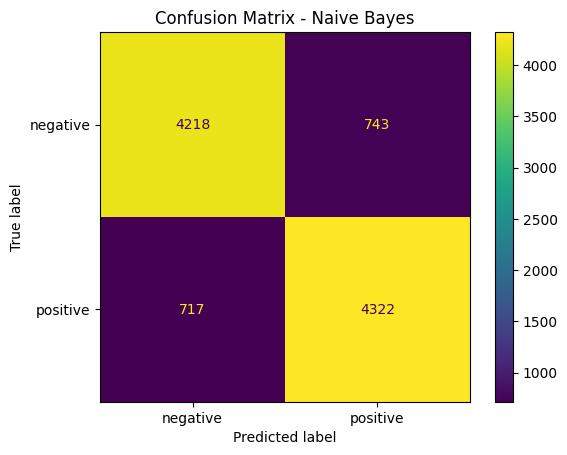

In [17]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Confusion Matrix - Naive Bayes")
plt.show()

**Notebook Created by:** [Md. Nazmul Hossain](https://nazmul-1117.github.io)\
**Course Code:** CSE 412 223_D4\
**Course Name:** Machine Learning Lab\
**Date:** 13 March 2026\
**Purpose:** IMDb Sentiment Analysis using Naive Bayes\
**Dataset**: [IMDB Dataset of 50K Movie Reviews](https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews)